# Analysis of Deconvolved 10k Windows

**Background:** 
Switched deconvolution from gene/origin centric to the entire genome. This will now require an API to load the approporiate 10k window (and stitch if needed) for gene and origin analysis. And for transcription factor and nucleosome-centric analyses.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolve_genome_g0066_10k_10x10_2024_09_20"

analysis = GenomeDeconvolutionAnalysis(outdir)

In [3]:
from src.geneset import get_deconvolved_geneset

genes = get_deconvolved_geneset()

In [104]:
gene = genes.iloc[10]

tss = gene['TSS']
chrom = gene.chr
span = tss-3000, tss+3000

gene_data, loaded_span = analysis.load_mnase_span(chrom, span)

(34450, 40450)

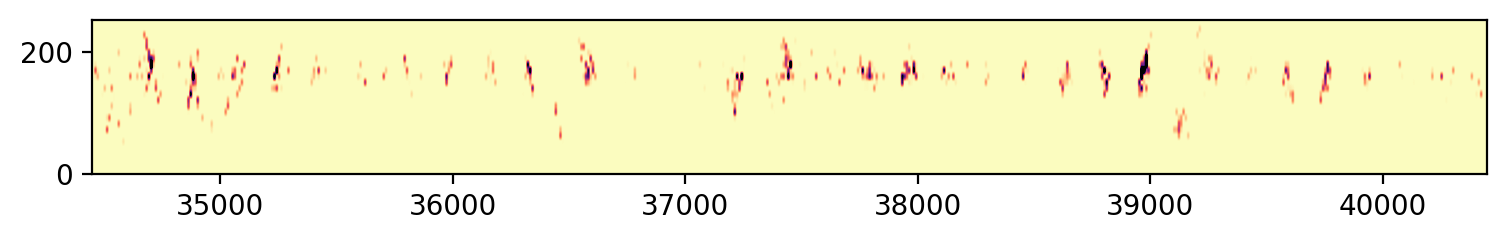

In [106]:

plt.figure(figsize=(9, 1))
plt.imshow(gene_data[100], origin='lower', cmap='magma_r', vmax=10, aspect='auto',
          extent=[loaded_span[0], loaded_span[1], 0, GlobalConstants.MAX_Y_LEN])
loaded_span